In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 
import plotly.express as px
 

colnames=["age", "workclass","fnlwgt", "education", "education-num" , "marital-status", "occupation",
          "relationship", "race", "sex", "capital-gain", "capital-loss", 
          "hours-per-week", "native-country", "income"] 
df = pd.read_csv('adult.data', names=colnames, header=None)

def col_filter(x):
    if isinstance(x, str):  # check if x is str
        return x.strip() if x.strip() != '?' else None
    else:
        return x

possible_values = {}
df_filtered = pd.DataFrame()  # empty dataframe to store updated values

for col in colnames:

    
    df_filtered[col] = df[col].apply(col_filter)
    all_attributes = col, df_filtered[col].unique()
#     print(all_attributes[0])


    possible_values[col] = all_attributes[1]



/home/shithi/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


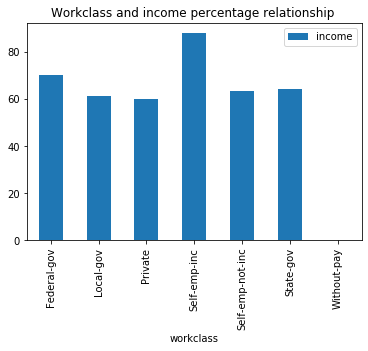

In [66]:
##### Story 1 : workclass and income relationship

df_scenerio1 = df_filtered[["workclass", "income"]] #taking two columns in pd data frame



df_scenerio1["income"] = df_scenerio1["income"].apply(
    lambda x: 0 if x == "<=50K" else 1
)

# print(df_scenerio1)

df_new = df_scenerio1.groupby(["workclass"]).mean()

df_new["income"] = df_new["income"].apply(
    lambda x: x*100
)

df_new = df_new.reset_index()   #using reset we can ungroup 
# print(df_new)
        
 
ax = df_new.plot.bar(x="workclass", y="income", rot=90)
plt.title("Workclass and income percentage relationship ")
plt.show()

    

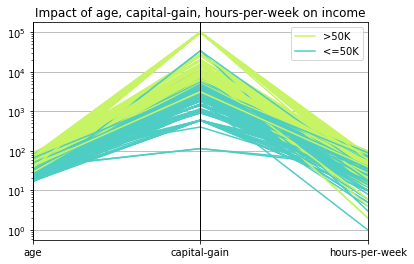

In [65]:
# Story 3 To explore the relationship between age, capital gain, and hours-per-week concerning income, as requested by the marketing department.
df_scenerio2 = df_filtered[["race", "capital-gain","hours-per-week", "income" ]]



df_filtered = df_filtered[df_filtered["capital-gain"] != 0] # we are filtering the data where capital gain is zero. other wise our graph doesn't look good.
pd.plotting.parallel_coordinates(df_filtered.sample(1000), 'income', cols=['age',  'capital-gain', 'hours-per-week'], color=('#C7F464','#4ECDC4',))
plt.yscale("log")

plt.title("Impact of age, capital-gain, hours-per-week on income")
plt.show()

(array([0, 1, 2, 3, 4]), <a list of 5 Text xticklabel objects>)

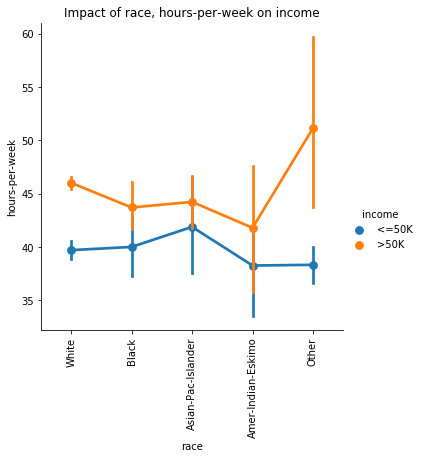

In [62]:
## Story2 : relationship between race, hours-per-week and income
import seaborn as sns
sns.catplot(df_filtered, x="race", y="hours-per-week", hue="income", kind="point")
plt.title("Impact of race, hours-per-week on income")
plt.xticks(rotation=90)


Text(0.5, 1, 'Capital-gain distribution on income')

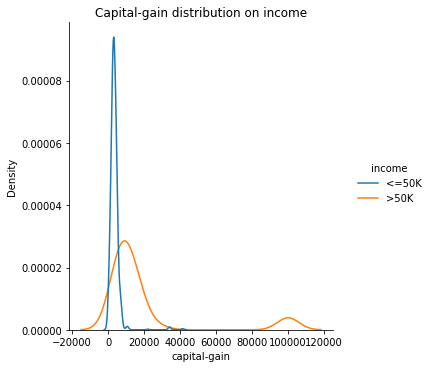

In [60]:
## Story -4  relationship between income and density
import seaborn as sns
sns.displot(
    df_filtered, x="capital-gain", hue="income", kind="kde"
)

/home/shithi/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  
/home/shithi/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  del sys.path[0]
/home/shithi/anaconda3/lib/python3.7/site-packages/geopandas/plotting.py:51: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  if geom is not None and ge

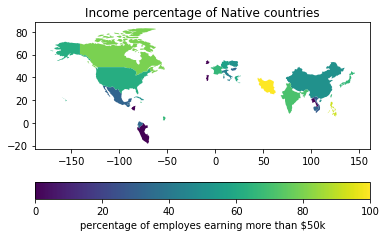

In [61]:
#story -5 native country and income relationship 

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

country_income = df_filtered[["native-country", "income"]]
country_income["name"] = country_income["native-country"]



country_income["income"] = country_income["income"].apply(
    lambda x: 0 if x == "<=50K" else 1
)



df_new_one = country_income.groupby(["name"]).mean()

df_new_one["income"] = df_new_one["income"].apply(
    lambda x: x*100
)

world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
world['name'] = world['name'].replace("United States of America", "United-States")

map = pd.merge(df_new_one, world, how="inner", on=["name"])
map_gpd = gpd.GeoDataFrame(map)
map_gpd.plot(
    column= 'income',
    legend=True,
    legend_kwds={'label': "percentage of employes earning more than $50k",
                        'orientation': "horizontal"}
                 );

plt.title("Income percentage of Native countries")
plt.show()



In [23]:
df_new_one.sort_values('income')

,income
name,
Ireland,0.000000
Portugal,0.000000
Peru,0.000000
Columbia,0.000000
Nicaragua,0.000000
Laos,0.000000
Vietnam,28.571429
Mexico,31.818182
Hungary,33.333333


In [52]:
import collections
collections.Counter(country_income["name"].tolist())

Counter({'United-States': 2471,
         None: 54,
         'Taiwan': 3,
         'Canada': 10,
         'Japan': 9,
         'Mexico': 22,
         'Italy': 7,
         'Dominican-Republic': 2,
         'Cambodia': 3,
         'India': 14,
         'Greece': 5,
         'Poland': 6,
         'Guatemala': 3,
         'Columbia': 3,
         'Iran': 5,
         'El-Salvador': 9,
         'Germany': 14,
         'Ecuador': 3,
         'Philippines': 13,
         'Vietnam': 7,
         'Puerto-Rico': 7,
         'South': 5,
         'Nicaragua': 2,
         'Peru': 1,
         'China': 4,
         'England': 8,
         'Ireland': 2,
         'Cuba': 6,
         'Hungary': 3,
         'Yugoslavia': 1,
         'France': 3,
         'Laos': 1,
         'Portugal': 2,
         'Jamaica': 3,
         'Scotland': 1})